# Is LOFO's ceiling set by the data, or by method?

Every LOFO intervention this project has tried (pc_ttp, pc_recenter, DANN, CORAL,
lofo_ae) either helped a little or didn't help at all -- none closed the gap. This
notebook tries to actually answer *why*, rather than keep guessing: is the remaining
gap a genuine cross-chip generalization problem a better method could still close, or
is it a coverage/sample-size ceiling no method can close because the information
needed simply isn't in the data?

Four independent checks, each targeting a different possible explanation:

1. **Coverage map** -- which (target, concentration) combinations actually exist on
   each chip. Each chip only has 8 non-control wells for up to 5 targets x 3
   concentrations (15 possible combos) -- most combos can't all fit on one chip.
2. **LOFO-specific coverage gaps** -- for each held-out chip, how many of its samples
   belong to a (target, concentration) combo that *no* training chip has *any*
   example of. These are provably unlearnable, not a generalization failure.
3. **Within-chip vs. cross-chip spread** -- for combos with enough replicate wells,
   is cross-chip disagreement actually bigger than the noise between replicate wells
   on the *same* chip? If not, "chip effects" may be smaller than they look.
4. **In-distribution ceiling** -- how well do these models do when train/test come
   from the *same* chips (kfold/random_split), not held-out chips? A big gap between
   that number and LOFO is the classic signature of a real generalization problem;
   a small gap points at coverage/sample-size being the actual ceiling.

Uses raw, **unfiltered** well data (bypasses `config.apply_well_exclusion`) for the
coverage checks specifically -- the point is to see everything that was ever
measured, not whatever subset a particular group's modeling policy keeps.

In [1]:
import os
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        notebook_dir = os.path.dirname(os.path.dirname(notebook_path))
        os.chdir(notebook_dir)
except Exception as e:
    print(f"Could not change directory: {e}")

print("Current Working Directory:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config

cdt = importlib.import_module("04_cross_dataset_training")

%matplotlib inline

Current Working Directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main

[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## 1. Configuration

In [2]:
GROUP_NAME = "final_4_chip_clean_nn"   # any group over the same 4 chips works -- exclusion policy doesn't matter below, we bypass it
EXP_FOLDER = config.FINAL_EXP_FOLDER + "_nc_subtract"
CURVE_TYPE = "ori_curve_wavelet_bior35_norm"

folder_names = config.CROSS_DATASET_GROUPS[GROUP_NAME]
exp_paths = [Path(EXP_FOLDER, name) for name in folder_names]

def short_name(folder):
    return folder.split('_U_', 1)[1]

print(f"{len(folder_names)} chips:")
for n in folder_names:
    print(" -", n, f"({short_name(n)})")

4 chips:
 - D20260806_E00_C00_F4500KHz_U_DDM_01_06 (DDM_01_06)
 - D20260807_E00_C00_F4500KHz_U_DDM_02_07 (DDM_02_07)
 - D20260808_E00_C00_F4500KHz_U_DDM_03_01 (DDM_03_01)
 - D20260810_E00_C00_F4500KHz_U_DDM_04_01 (DDM_04_01)


## 2. Load raw, unfiltered well-level data

One row per **well** (not per pixel) -- `config.LABEL_MAPPINGS` gives the target
name, `concentration` the raw concentration string, straight from
`curve_for_training.joblib`, with **no** `apply_well_exclusion` applied. This is the
true experimental design as measured, before any modeling policy trims it down.

In [3]:
def load_raw_well_table(exp_path):
    data = joblib.load(Path(exp_path) / config.TRAINING_DATA_PATH)
    mapping = config.LABEL_MAPPINGS[exp_path.name]
    Y_well_raw = np.asarray(data["Y_well"])
    Y_mapped = np.array([mapping.get(w, w) for w in Y_well_raw])
    conc_raw = data.get("concentration")
    conc = np.asarray(conc_raw, dtype=object) if conc_raw is not None else np.full(len(Y_well_raw), None, dtype=object)

    metadata_df = pd.DataFrame(data["metadata"]) if "metadata" in data else None
    if metadata_df is not None and "well_id" in metadata_df.columns:
        well_id = metadata_df["well_id"].values
    else:
        well_id = Y_well_raw

    df = pd.DataFrame({"well_id": well_id, "target": Y_mapped, "concentration": conc})
    wells = df.drop_duplicates("well_id").copy()
    wells["chip"] = short_name(exp_path.name)
    wells["n_pixels"] = df.groupby("well_id").size().reindex(wells["well_id"]).values
    return wells


all_wells = pd.concat([load_raw_well_table(p) for p in exp_paths], ignore_index=True)
print(f"{len(all_wells)} total wells across {len(folder_names)} chips ({len(all_wells)/len(folder_names):.0f}/chip)")
all_wells

35 total wells across 4 chips (9/chip)


,well_id,target,concentration,chip,n_pixels
0,0,IAV,1000000,DDM_01_06,1970
1,1,IAV,100000,DDM_01_06,1949
2,2,IAV,10000,DDM_01_06,1858
3,3,IBV,10000,DDM_01_06,1907
4,4,Kp,100000,DDM_01_06,1921
5,5,Cov,1000000,DDM_01_06,1848
6,6,Hadv,1000000,DDM_01_06,1919
7,9,NC-ALL,0,DDM_01_06,1135
8,0,IBV,1000000,DDM_02_07,1047
9,1,IBV,100000,DDM_02_07,1799


## 3. Coverage map -- which (target, concentration) exists on which chip

Rows = (target, concentration), columns = chip, cell = well count (blank = absent
entirely). PC/NC are controls, not part of the target x concentration design --
shown separately.

In [4]:
targets_df = all_wells[~all_wells["target"].isin(["PC"]) & ~all_wells["target"].astype(str).str.startswith("NC")]
control_df = all_wells[all_wells["target"].isin(["PC"]) | all_wells["target"].astype(str).str.startswith("NC")]

coverage = targets_df.pivot_table(index=["target", "concentration"], columns="chip",
                                   values="well_id", aggfunc="count", fill_value=0)
n_chips = len(folder_names)
coverage["n_chips_present"] = (coverage > 0).sum(axis=1)
coverage = coverage.sort_values(["target", "concentration"])
print(f"{len(coverage)} distinct (target, concentration) combinations found across all {n_chips} chips "
     f"(out of up to {targets_df['target'].nunique()} targets x {targets_df['concentration'].nunique()} concentrations "
     f"= {targets_df['target'].nunique() * targets_df['concentration'].nunique()} possible).")
print(f"Combos present on all {n_chips} chips: {(coverage['n_chips_present'] == n_chips).sum()} / {len(coverage)}")
print(f"Combos present on only 1 chip: {(coverage['n_chips_present'] == 1).sum()} / {len(coverage)}")
coverage

15 distinct (target, concentration) combinations found across all 4 chips (out of up to 5 targets x 3 concentrations = 15 possible).
Combos present on all 4 chips: 0 / 15
Combos present on only 1 chip: 2 / 15


chip                  DDM_01_06  DDM_02_07  DDM_03_01  DDM_04_01  \
target concentration                                               
Cov    10000                  0          0          1          1   
       100000                 0          1          0          1   
       1000000                1          0          0          1   
Hadv   10000                  0          1          0          0   
       100000                 0          0          0          1   
       1000000                1          0          1          0   
IAV    10000                  1          0          1          0   
       100000                 1          1          0          0   
       1000000                1          1          0          1   
IBV    10000                  1          1          0          1   
       100000                 0          1          1          0   
       1000000                0          1          1          0   
Kp     10000                  0          1          1          0   
       100000                 1          0          1          1   
       1000000                0          0          1          1   

chip                  n_chips_present  
target concentration                   
Cov    10000                        2  
       100000                       2  
       1000000                      2  
Hadv   10000                        1  
       100000                       1  
       1000000                      2  
IAV    10000                        2  
       100000                       2  
       1000000                      3  
IBV    10000                        3  
       100000                       2  
       1000000                      2  
Kp     10000                        2  
       100000                       3  
       1000000                      2

In [5]:
print("Controls (PC/NC) -- these exist independent of the target x concentration design:")
control_df.pivot_table(index="target", columns="chip", values="well_id", aggfunc="count", fill_value=0)

Controls (PC/NC) -- these exist independent of the target x concentration design:


chip,DDM_01_06,DDM_02_07,DDM_03_01,DDM_04_01
target,,,,
NC-ALL,1,1,1,1


## 4. LOFO-specific coverage gaps

For each chip, if it were held out: how many of *its own* wells belong to a
(target, concentration) combo that **no other chip has any example of**? Those
samples are provably outside what the model could have learned, regardless of
method -- not a generalization failure, an extrapolation problem.

In [6]:
rows = []
for held_out in folder_names:
    ho_short = short_name(held_out)
    train_wells = targets_df[targets_df["chip"] != ho_short]
    ho_wells = targets_df[targets_df["chip"] == ho_short]

    train_combos = set(zip(train_wells["target"], train_wells["concentration"]))
    ho_combos = ho_wells.assign(combo=list(zip(ho_wells["target"], ho_wells["concentration"])))

    unseen_mask = ~ho_combos["combo"].isin(train_combos)
    n_unseen_wells = int(unseen_mask.sum())
    n_unseen_pixels = int(ho_combos.loc[unseen_mask, "n_pixels"].sum())
    total_pixels = int(ho_combos["n_pixels"].sum())

    unseen_combos = sorted(set(ho_combos.loc[unseen_mask, "combo"]))
    rows.append({
        "held_out_chip": ho_short,
        "n_wells_total": len(ho_wells), "n_wells_unseen_combo": n_unseen_wells,
        "pct_pixels_unseen_combo": 100 * n_unseen_pixels / total_pixels if total_pixels else float("nan"),
        "unseen_combos": unseen_combos,
    })

gap_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 200)
gap_df

,held_out_chip,n_wells_total,n_wells_unseen_combo,pct_pixels_unseen_combo,unseen_combos
0,DDM_01_06,7,0,0.000000,[]
1,DDM_02_07,8,1,13.883595,"[(Hadv, 10000)]"
2,DDM_03_01,8,0,0.000000,[]
3,DDM_04_01,8,1,12.733469,"[(Hadv, 100000)]"


## 5. Within-chip vs. cross-chip spread

For (target, concentration) combos with >=2 replicate wells on at least one chip:
compare well-to-well curve distance *within* that chip against the distance between
different chips' mean curves for the *same* combo. If cross-chip distances aren't
much bigger than within-chip distances, "chip effects" aren't the dominant source of
disagreement for that combo -- if they are much bigger, that's real evidence of a
genuine, not just noisy, chip effect.

First check *how many* combos even have within-chip replicates to compare against --
if that number is 0 or near it, chip effects and replicate noise are structurally
confounded (every combo is 1 well = 1 chip = 1 data point), which is itself an
important finding, not just a reason the comparison below comes up empty.

In [7]:
replicate_counts = targets_df.groupby(["chip", "target", "concentration"]).size()
print("Wells per (chip, target, concentration) combo -- distribution:")
print(replicate_counts.value_counts().sort_index())
print(f"\n{(replicate_counts >= 2).sum()} / {len(replicate_counts)} (chip, target, concentration) groups "
     f"have >=2 replicate wells on that chip.")

Wells per (chip, target, concentration) combo -- distribution:
1    31
Name: count, dtype: int64

0 / 31 (chip, target, concentration) groups have >=2 replicate wells on that chip.


In [8]:
combined = cdt.combine_group(exp_paths, GROUP_NAME, curve_type=CURVE_TYPE)
curves = np.asarray(combined["curves"])
dataset_id = np.asarray(combined["dataset_id"])
y_mapped = np.asarray(combined["Y_mapped"])
well_ids = np.asarray(combined["well_ids"]) if combined.get("well_ids") is not None else None
conc_raw = np.asarray(combined.get("concentration_raw"), dtype=object) if combined.get("concentration_raw") is not None else None

def chip_short(dsid):
    return short_name(str(dsid))

rows = []
if well_ids is not None and conc_raw is not None:
    df = pd.DataFrame({"well_id": well_ids, "chip": [chip_short(d) for d in dataset_id],
                       "target": y_mapped, "concentration": conc_raw, "row_idx": np.arange(len(curves))})
    for (target, conc), grp in df.groupby(["target", "concentration"]):
        if str(target).startswith("NC") or target == "PC":
            continue
        well_means = grp.groupby("well_id").agg(chip=("chip", "first"), row_idx=("row_idx", list))
        if len(well_means) < 2:
            continue
        well_curve_means = {w: curves[idx].mean(axis=0) for w, idx in well_means["row_idx"].items()}

        within_dists, cross_dists = [], []
        for chip, sub in well_means.groupby("chip"):
            if len(sub) >= 2:
                wm = np.stack([well_curve_means[w] for w in sub.index])
                for i in range(len(wm)):
                    for j in range(i + 1, len(wm)):
                        within_dists.append(np.linalg.norm(wm[i] - wm[j]))
        chip_means = {chip: np.stack([well_curve_means[w] for w in sub.index]).mean(axis=0)
                     for chip, sub in well_means.groupby("chip")}
        chips_here = list(chip_means.keys())
        for i in range(len(chips_here)):
            for j in range(i + 1, len(chips_here)):
                cross_dists.append(np.linalg.norm(chip_means[chips_here[i]] - chip_means[chips_here[j]]))

        if within_dists and cross_dists:
            rows.append({
                "target": target, "concentration": conc,
                "n_chips_with_replicates": sum(1 for _, sub in well_means.groupby("chip") if len(sub) >= 2),
                "n_chips_total": len(chips_here),
                "within_chip_dist_mean": np.mean(within_dists),
                "cross_chip_dist_mean": np.mean(cross_dists),
                "ratio (cross/within)": np.mean(cross_dists) / np.mean(within_dists) if np.mean(within_dists) > 0 else float("inf"),
            })

if rows:
    spread_df = pd.DataFrame(rows).sort_values("ratio (cross/within)", ascending=False)
    print("ratio >> 1 means cross-chip disagreement dwarfs within-chip well-to-well noise -- a real chip effect for that combo.")
    print("ratio ~ 1 means cross-chip disagreement is no bigger than ordinary replicate noise.")
else:
    spread_df = pd.DataFrame(columns=["target", "concentration", "n_chips_with_replicates",
                                      "n_chips_total", "within_chip_dist_mean",
                                      "cross_chip_dist_mean", "ratio (cross/within)"])
    print("No (target, concentration) combo had >=2 replicate wells on any chip -- "
         "see the replicate-count check above. Within-chip noise and cross-chip/chip "
         "effects are structurally confounded for this group; this comparison can't "
         "be made from this data as collected.")
spread_df

  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_clean_nn']: dropping 1135 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_clean_nn']: dropping 5523 samples from wells [6, 7, 8, 9] (y_label={6: 'Cov', 7: 'Hadv', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+05', 7: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260807_E00_C00_F4500KHz_U_DDM_02_07
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_clean_nn']: dropping 3570 samples from wells [6, 8, 9] (y_label={6: 'Cov', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260808_E00_C00_F4500KHz_U_DDM_03_01
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_clean_nn']: dropping 1315 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260810_E00_C00_F4500KHz_U_DDM_04_01
  [*] Resampling curves onto common grid: 733 points, durati

,target,concentration,n_chips_with_replicates,n_chips_total,within_chip_dist_mean,cross_chip_dist_mean,ratio (cross/within)


## 6. In-distribution ceiling (kfold/random_split vs. LOFO)

If results already exist for this group under `--mode kfold` or `--mode
random_split`, compare accuracy against LOFO for the same models -- a big gap is the
classic domain-shift signature (real generalization problem); a small gap points at
coverage/sample-size being the actual ceiling, since kfold/random_split has no
cross-chip extrapolation to do at all. If nothing is found, this cell says exactly
what to run to get the number instead of guessing.

In [9]:
from cross_dataset_result_io import load_partitioned

def out_dir_for(group_name, curve_alignment="acquisition_start", pc_ttp_anchor="min"):
    out_dir = Path(EXP_FOLDER) / "cross_dataset_cv" / group_name
    if curve_alignment == "pc_ttp":
        out_dir = out_dir / "curve_alignment_pc_ttp" / f"anchor_{pc_ttp_anchor}"
    return out_dir


def summarize_mode(group_name, mode_str, curve_type=CURVE_TYPE, curve_alignment="acquisition_start", pc_ttp_anchor="min"):
    out_dir = out_dir_for(group_name, curve_alignment, pc_ttp_anchor)
    lofo_results = load_partitioned(out_dir, mode_str, curve_type)
    if not lofo_results:
        return None
    rows = []
    for fold_label, fold_res in lofo_results.items():
        if fold_label == "full_data" or not isinstance(fold_res, dict):
            continue
        for filt, res_entry in fold_res.items():
            if not isinstance(res_entry, dict):
                continue
            for model_key, (preds_key, _, _) in config.MODEL_KEY_MAP.items():
                if preds_key not in res_entry:
                    continue
                y_true = res_entry.get("y_trues_")
                preds = res_entry.get(preds_key)
                if not y_true or not preds:
                    continue
                accs = [np.mean(np.asarray(yt) == np.asarray(yp)) for yt, yp in zip(y_true, preds)]
                rows.append({"mode": mode_str, "fold": fold_label, "filter": filt, "model": model_key,
                            "acc": float(np.mean(accs))})
    return pd.DataFrame(rows) if rows else None


lofo_summary = summarize_mode(GROUP_NAME, "lofo")
kfold_summary = summarize_mode(GROUP_NAME, "kfold5")
rs_summary = summarize_mode(GROUP_NAME, "random_split")

for label, df_ in [("lofo", lofo_summary), ("kfold5", kfold_summary), ("random_split", rs_summary)]:
    if df_ is None:
        print(f"[NOT FOUND] no '{label}' results for group={GROUP_NAME} curve_type={CURVE_TYPE} -- "
             f"run: python 04_cross_dataset_training.py --task_id <id> --mode {label if label != 'lofo' else 'lofo'} "
             f"--curve_type {CURVE_TYPE} --models cnn_gru_dual --outlier_filter none --train_full")
    else:
        print(f"[{label}] {len(df_)} rows, mean acc by model:")
        print(df_.groupby("model")["acc"].mean().sort_values(ascending=False))
    print()

[NOT FOUND] no 'lofo' results for group=final_4_chip_clean_nn curve_type=ori_curve_wavelet_bior35_norm -- run: python 04_cross_dataset_training.py --task_id <id> --mode lofo --curve_type ori_curve_wavelet_bior35_norm --models cnn_gru_dual --outlier_filter none --train_full

[NOT FOUND] no 'kfold5' results for group=final_4_chip_clean_nn curve_type=ori_curve_wavelet_bior35_norm -- run: python 04_cross_dataset_training.py --task_id <id> --mode kfold5 --curve_type ori_curve_wavelet_bior35_norm --models cnn_gru_dual --outlier_filter none --train_full

[NOT FOUND] no 'random_split' results for group=final_4_chip_clean_nn curve_type=ori_curve_wavelet_bior35_norm -- run: python 04_cross_dataset_training.py --task_id <id> --mode random_split --curve_type ori_curve_wavelet_bior35_norm --models cnn_gru_dual --outlier_filter none --train_full



## 7. Proof 3 -- UMAP/t-SNE: does chip or target dominate the raw curve space?

Sections 3-6 argue the coverage/replication case numerically. This is the visual
version, on the raw curves directly (no trained model involved -- this is a claim
about the *data*, not about what any particular model learned): reduce the same
points to 2D twice, color once by target, once by chip. If chip forms tight,
separated clusters while target doesn't, that's a direct visual demonstration that
whatever a classifier's embedding space eventually looks like, it's starting from
raw input where domain (chip) structure is more prominent than the biological
signal the model is actually supposed to key on.

PC excluded (control, not a target). Subsampled per chip for tractability and so no
one chip dominates the plot by sample count alone. Uses UMAP if installed, falls
back to t-SNE (scikit-learn, always available) otherwise -- both are standard for
this; UMAP is faster and usually preserves more global structure, t-SNE is finicky
about `perplexity` but ubiquitous.

In [ ]:
try:
    import umap
    REDUCER_NAME = "UMAP"
except ImportError:
    from sklearn.manifold import TSNE
    REDUCER_NAME = "t-SNE"

plot_mask = y_mapped != "PC"
rng = np.random.default_rng(0)
N_PER_CHIP = 1500
sub_idx = []
for chip in np.unique(dataset_id[plot_mask]):
    chip_pos = np.where(plot_mask & (dataset_id == chip))[0]
    sub_idx.append(rng.choice(chip_pos, size=min(N_PER_CHIP, len(chip_pos)), replace=False))
sub_idx = np.concatenate(sub_idx)

X_sub = curves[sub_idx]
chip_sub = np.array([short_name(str(c)) for c in dataset_id[sub_idx]])
target_sub = y_mapped[sub_idx]

print(f"Reducing {len(X_sub)} raw curves ({X_sub.shape[1]}-dim) via {REDUCER_NAME}...")
if REDUCER_NAME == "UMAP":
    embedding_2d = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(X_sub)
else:
    embedding_2d = TSNE(n_components=2, random_state=0, init="pca", perplexity=30).fit_transform(X_sub)
print("Done.")

Reducing 6000 raw curves (733-dim) via UMAP...


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


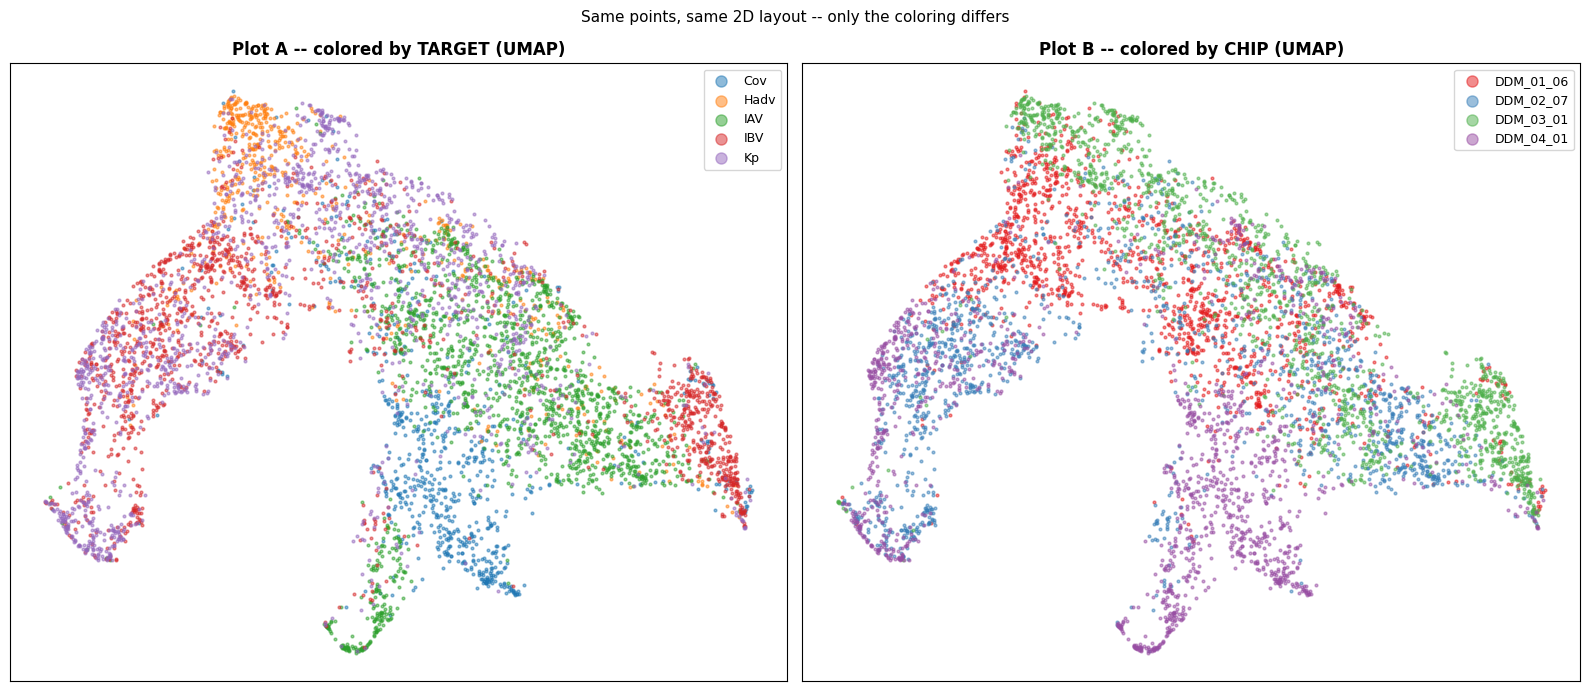

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

target_names = sorted(set(target_sub))
target_palette = {t: plt.cm.tab10(i % 10) for i, t in enumerate(target_names)}
for t in target_names:
    m = target_sub == t
    axes[0].scatter(embedding_2d[m, 0], embedding_2d[m, 1], s=4, alpha=0.5, color=target_palette[t], label=t)
axes[0].set_title(f"Plot A -- colored by TARGET ({REDUCER_NAME})", fontweight="bold")
axes[0].legend(markerscale=4, fontsize=9, loc="best")

chip_names_sub = sorted(set(chip_sub))
chip_palette = {c: plt.cm.Set1(i % 9) for i, c in enumerate(chip_names_sub)}
for c in chip_names_sub:
    m = chip_sub == c
    axes[1].scatter(embedding_2d[m, 0], embedding_2d[m, 1], s=4, alpha=0.5, color=chip_palette[c], label=c)
axes[1].set_title(f"Plot B -- colored by CHIP ({REDUCER_NAME})", fontweight="bold")
axes[1].legend(markerscale=4, fontsize=9, loc="best")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Same points, same 2D layout -- only the coloring differs", fontsize=11)
plt.tight_layout()
plt.show()

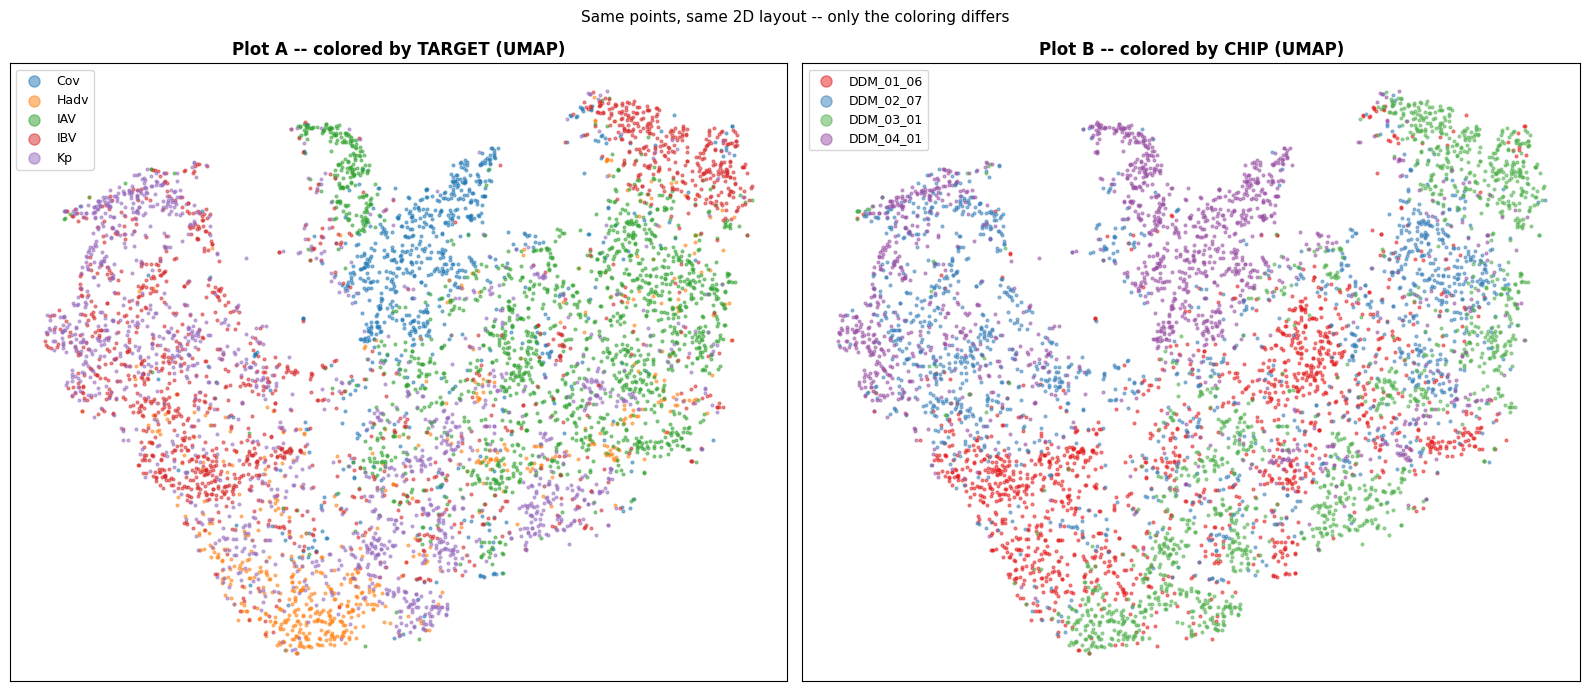

In [ ]:
from sklearn.manifold import TSNE

embedding_2d_tsne = TSNE(n_components=2, random_state=0, init="pca", perplexity=30).fit_transform(X_sub)

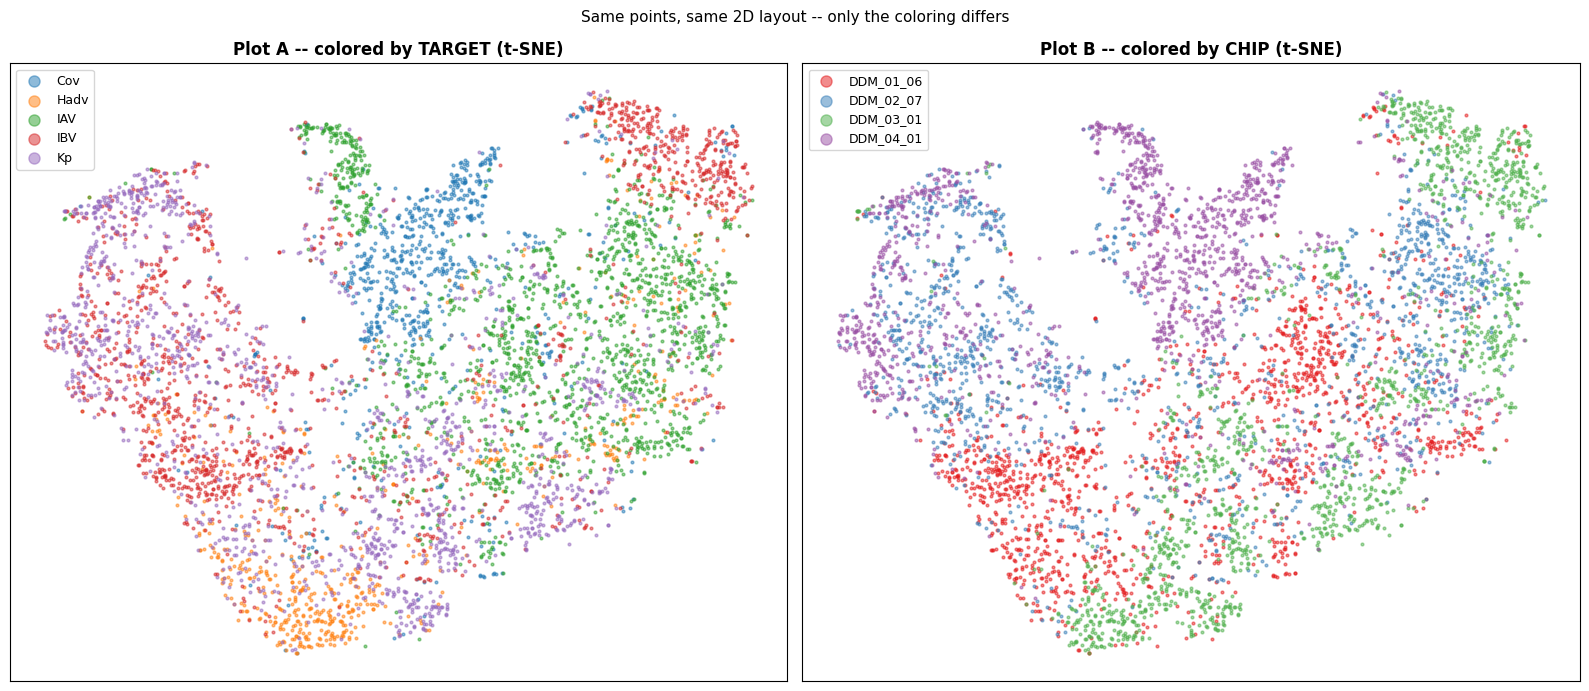

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

target_names = sorted(set(target_sub))
target_palette = {t: plt.cm.tab10(i % 10) for i, t in enumerate(target_names)}
for t in target_names:
    m = target_sub == t
    axes[0].scatter(embedding_2d_tsne[m, 0], embedding_2d_tsne[m, 1], s=4, alpha=0.5, color=target_palette[t], label=t)
axes[0].set_title(f"Plot A -- colored by TARGET (t-SNE)", fontweight="bold")
axes[0].legend(markerscale=4, fontsize=9, loc="best")

chip_names_sub = sorted(set(chip_sub))
chip_palette = {c: plt.cm.Set1(i % 9) for i, c in enumerate(chip_names_sub)}
for c in chip_names_sub:
    m = chip_sub == c
    axes[1].scatter(embedding_2d_tsne[m, 0], embedding_2d_tsne[m, 1], s=4, alpha=0.5, color=chip_palette[c], label=c)
axes[1].set_title(f"Plot B -- colored by CHIP (t-SNE)", fontweight="bold")
axes[1].legend(markerscale=4, fontsize=9, loc="best")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Same points, same 2D layout -- only the coloring differs", fontsize=11)
plt.tight_layout()
plt.show()

### Quantitative backup, not just eyeballing

A plot can look more or less separated depending on point size/alpha/palette choice
-- silhouette score is the standard, palette-independent way to say "how well does
*this* labeling explain the *shape* of the point cloud," from -1 (labeling is
actively wrong for this geometry) to +1 (labeling matches tight, separated
clusters). Computed on the same 2D layout, once per labeling.

In [12]:
from sklearn.metrics import silhouette_score

sil_chip = silhouette_score(embedding_2d, chip_sub)
sil_target = silhouette_score(embedding_2d, target_sub)
print(f"Silhouette score by CHIP:   {sil_chip:+.3f}")
print(f"Silhouette score by TARGET: {sil_target:+.3f}")

if sil_chip > sil_target + 0.1:
    verdict = "much better"
elif abs(sil_chip - sil_target) <= 0.1:
    verdict = "about the same as"
else:
    verdict = "worse than"
print(f"\nChip labeling explains the point cloud's shape {verdict} target labeling does.")

Silhouette score by CHIP:   +0.000
Silhouette score by TARGET: -0.066

Chip labeling explains the point cloud's shape about the same as target labeling does.


In [15]:
from sklearn.metrics import silhouette_score

sil_chip_tsne = silhouette_score(embedding_2d_tsne, chip_sub)
sil_target_tsne = silhouette_score(embedding_2d_tsne, target_sub)
print(f"Silhouette score by CHIP:   {sil_chip_tsne:+.3f}")
print(f"Silhouette score by TARGET: {sil_target_tsne:+.3f}")

if sil_chip_tsne > sil_target_tsne + 0.1:
    verdict = "much better"
elif abs(sil_chip_tsne - sil_target_tsne) <= 0.1:
    verdict = "about the same as"
else:
    verdict = "worse than"
print(f"\nChip labeling explains the point cloud's shape {verdict} target labeling does.")

Silhouette score by CHIP:   +0.006
Silhouette score by TARGET: -0.045

Chip labeling explains the point cloud's shape about the same as target labeling does.


## 8. Summary

Read together:
- **Section 3**: if most of the (target, concentration) grid is only ever seen on
  1-2 chips, LOFO is frequently being asked to extrapolate to combinations no
  training chip demonstrated -- a coverage problem, not a method problem.
- **Section 4**: quantifies exactly how much of each held-out chip's data falls into
  that "never seen in training" bucket -- the provable floor on LOFO accuracy no
  method can get past.
- **Section 5**: `ratio >> 1` on real, non-control combos is direct evidence of a
  genuine (not just noisy) chip effect for that specific combo -- worth cross-
  referencing against which classes(Kp/IBV in earlier LOFO results) actually
  under-perform.
- **Section 6**: a large kfold/random_split-vs-LOFO gap says there's real headroom a
  better cross-chip method could still capture; a small gap says LOFO is already
  close to what the data supports, and more chips (not more methods) is the lever
  left to pull.